# UK Biobank — Academic Impact III: the author arm

The other two 03 notebooks ask what UK Biobank publishes and how well it lands, counted by
**field**. This one asks the same question counted by **person**: who produced that body of
work, how the contribution is spread across the researchers who entered the literature at
different times, and which forms of influence the leading contributors actually hold.

**Two sources, one job each.**

| source | supplies |
|---|---|
| `data/showcase/showcase+/showcase_plus_all_endpoint.parquet` (`P.SHOWCASE_PLUS`) | **authorship** — the `authors` field, and nothing else |
| the 03 API pathway (`P.FOR_COUNTS_API`) | **every citation quantity**, through `AI.paper_impact` |

That split is the point of this notebook's 2026-08-26 reconcile and is not a convenience.
The parquet also carries `times_cited` and `field_citation_ratio`, and this notebook used to
read them — which put the author arm on a different citation snapshot from every other
number in analysis 03, and on a **top-decile cut-off pooled across all years and fields**.
The pooled cut-off is mostly a measure of paper age (it called 30.8% of 2014's papers
top-decile and 5.4% of 2024's), so an entry-cohort figure built on it rewarded whoever
published earliest. See §4.

**One window, and it is the shared one: 2015–2025** (D19), normalised within ANZSRC 2020
Fields of Research at L4. The analysis set is the same **22,730 papers** the field notebooks
report, asserted in §4 rather than assumed.

**Two figures remain in this notebook**

1. **Author-entry cohort contribution profile** — the main-paper candidate for Fig. 3a.
2. **Influential-author fingerprint heatmap** — what each leading contributor is ahead on.

The former **author impact portfolio map** is now Figure 5G, built and exported by `05_author_characteristics.ipynb`. This notebook still owns its underlying normalized-citation author summary because the cohort and fingerprint analyses use the same table, but it no longer draws or exports a duplicate portfolio figure.

> **Sibling notebook.** [`03_academic_impact_01_for_analysis.ipynb`](03_academic_impact_01_for_analysis.ipynb)
> is the field-level arm (ANZSRC Fields of Research). Everything the two must agree on about
> what a citation weight *is* lives in `src/utils/data_analysis_03_academic_impact_analysis.py`
> — cell-level there, and per paper here via `AI.paper_impact`. The RCDC arm of the same
> analysis is archived at `doc/archive/03_academic_impact_02_rcdc_analysis.ipynb`; the module
> still supports it.


## 0. Inputs expected

**Authorship** — the corpus parquet at `P.SHOWCASE_PLUS`:

```text
data/showcase/showcase+/showcase_plus_all_endpoint.parquet
```

Columns read: `id`, `year`, `authors` (JSON, parsed by `shared_showcase` per D2),
`authors_count`, `title`, `source_title`. Its citation columns are deliberately **not**
read.

**Citations** — three files under `P.FOR_COUNTS_API`, all written by
`src/utils/data_analysis_03_academic_impact_dimensions_api.py`:

| file | supplies |
|---|---|
| `api_ukbb_records.json` | one record per paper: `times_cited`, `field_citation_ratio`, `recent_citations`, `year`, `type`, `category_for_2020` |
| `api_whole.for.parquet` | `mean_cit` per (year, field) — the reference `n_mncs` divides by |
| `field_thresholds.for.csv` | the **measured** top-decile and median cut-offs per (year, field) |

`AI.paper_impact` joins the three and is the only thing in this notebook that decides what a
citation weight means. It raises rather than falling back to the parquet if the record cache
is missing — a silent fallback there is the defect this reconcile removed.

### The measures, and their coverage over 2015–2025

| measure | what it is | measured for |
|---|---|---|
| `n_mncs` | `times_cited` ÷ the mean of its own (year, field) — 1.0 = that field's average paper that year. **The headline** | **100%** of the analysis set |
| `n_top10f` | share of the paper's fields in which it clears that (year, field)'s **measured** decile cut-off | **98.0%** |
| `n_top50f` | the same against the measured median | 98.0% |
| `times_cited` | raw citation count. Feeds the h-index, the i10 and total citations only | 100% |

`n_top10f` is short of 100% because a cut-off is measured only where UK Biobank had ≥10
papers in the (year, field) cell — 73.8% of 2015's papers, 99.0% of 2025's. Papers in
unmeasured cells stay `NaN`; they are **not** counted as "did not make the decile".


In [1]:
# ============================================================
# 1. Setup, paths, parameters and plotting style
# ============================================================

import json
import re
import sys
import warnings
from pathlib import Path

# Anchor every path on the repo root regardless of where the notebook is launched
# from (repo root, src/, or src/data_analysis/). See shared_paths for the why.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
ROOT = P.bootstrap()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

# --- the two data sources, and the division of labour between them ---------------
# AUTHORSHIP comes from the corpus parquet: it is the only place the `authors` field
# exists. CITATIONS come from the 03 API pathway, never from the parquet — see §4 and
# AI.paper_impact for why that separation is not optional.
from utils.shared_showcase import load_showcase
from utils import data_analysis_03_academic_impact_analysis as AI

INPUT_PARQUET = P.SHOWCASE_PLUS
COUNTS_DIR = P.FOR_COUNTS_API

# --- ANALYSIS PARAMETERS ---------------------------------------------------------
# ONE window, and it is the SAME window as the field-level notebooks (D19): every UK
# Biobank measure in analysis 03 answers to 2015-2025. The floors are argued in §2 of
# 03_academic_impact_01_for_analysis.ipynb and are not restated here — this notebook
# takes them, it does not re-decide them. 2026 is a part-year and is excluded.
ANALYSIS_MIN = 2015
ANALYSIS_MAX = 2025

# The vocabulary the citation weights are normalised within. L4 (fine fields) is what
# the measured decile cut-offs were measured at.
FOR_LEVEL = "L4"

# Author entry cohorts, cut on the analysis window. Three even 3-year bins and a 2-year
# tail; the tail is genuinely recent rather than a label over years the metric cannot
# reach, which is what "2023-2025" was before this notebook was reconciled.
COHORT_BINS = [
    (2015, 2017, "2015–2017\nfoundational entrants"),
    (2018, 2020, "2018–2020\nexpansion entrants"),
    (2021, 2023, "2021–2023\nconsolidation entrants"),
    (2024, 2025, "2024–2025\nrecent entrants"),
]
cohort_order = [label for _, _, label in COHORT_BINS]

# --- project plotting style ------------------------------------------------------
# The palette, font sizes and output directory live in universal_settings.yml at the
# repo root (section style.notebooks.03_academic_impact) so every notebook draws from
# one file. This notebook carried its own COLOUR dict and mpl.rcParams.update until
# 2026-08-26 — the §6 violation the loader exists to prevent, kept only because
# restyling would have moved every figure. Every figure moved anyway when the citation
# measures were reconciled, so the local style went with them.
from utils.shared_style import load_style, savefig
STYLE = load_style("03_academic_impact")
# Two export switches rather than a palette override: the base style defaults to
# save=false because most notebooks are read on screen, and this one exists to export.
STYLE["save"] = True
STYLE["formats"] = ["pdf", "png", "svg"]

# An ORDERED sequence (cohorts, percentile ranks) needs a ramp, not the categorical
# palette — four categorical colours would say the cohorts are unrelated kinds rather
# than successive waves. The ramp is built from the palette's blue so it still belongs
# to the project's colours.
UKB_SEQ = LinearSegmentedColormap.from_list(
    "ukb_seq", ["#F5F8FC", "#AFC2DC", STYLE["colors"][3], "#1B2E4D"])
cohort_palette = [UKB_SEQ(v) for v in (0.18, 0.42, 0.68, 0.94)]
INK = UKB_SEQ(0.98)      # dark end of the ramp: readable text on a pale cell
GREY = STYLE["edgecolor"]

# --- outputs: one slug, and it is the 03 slug ------------------------------------
# Figures go through savefig() to STYLE["savedir"]; tables and text are written
# directly. These were written under `05_author_impact/` until 2026-08-26.
TABLE_DIR = P.OUTPUT_TABLES / "03_academic_impact"
TEXT_DIR = P.OUTPUT / "paper_text" / "03_academic_impact"
for d in (TABLE_DIR, TEXT_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:      ", ROOT)
print("authorship:", INPUT_PARQUET)
print("citations: ", COUNTS_DIR)
print("figures -> ", STYLE["savedir"], f"(save={STYLE['save']})")
print("tables  -> ", TABLE_DIR)
print(f"analysis window {ANALYSIS_MIN}-{ANALYSIS_MAX}, normalised within FOR {FOR_LEVEL}")


ROOT:       /Users/valler/Python/RA/20_years_of_ukb
authorship: /Users/valler/Python/RA/20_years_of_ukb/data/showcase/showcase+/showcase_plus_all_endpoints_wide.parquet
citations:  /Users/valler/Python/RA/20_years_of_ukb/data/analysis/academic_impact/for_counts_api
figures ->  output/figures/data_analysis/03_academic_impact (save=True)
tables  ->  /Users/valler/Python/RA/20_years_of_ukb/output/tables/03_academic_impact
analysis window 2015-2025, normalised within FOR L4


In [2]:
# ============================================================
# 2. Helpers
# ============================================================
# WHAT IS NO LONGER HERE, and why:
#
#   infer_col / norm_name_for_col  — fuzzy column matching against a candidate list.
#       The corpus parquet's columns are already canonical (`id`, `year`, `authors`,
#       `times_cited`), so the fuzzy branch never fired usefully and could only ever
#       bind the WRONG column silently — its substring test would have matched
#       `authors_count` for "authors" had the exact name been missing. Columns are
#       named directly in §3 instead.
#   safe_json_loads  — a local JSON/literal parser. D2: nested columns are parsed by
#       `shared_showcase`, which tries JSON first and falls back to a Python literal,
#       so the parquet and any legacy pickle both read. `load_showcase(parse=[...])`
#       does it at load time now.
#   winsorise  — never called.

def clean_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def normalise_name(x):
    """Fold a name to a comparison key: lowercase, punctuation to single spaces.

    This is the FALLBACK author key, used only where Dimensions gives no researcher_id
    (about an eighth of author slots). It is the weakest link in the author-level
    analysis in both directions: it merges two different people who publish under the
    same name, and it splits one person whose name is written two ways.
    """
    x = clean_str(x).lower()
    x = re.sub(r"[^a-z0-9]+", " ", x)
    return re.sub(r"\s+", " ", x).strip()


def mode_or_blank(s):
    s = pd.Series(s).dropna().astype(str)
    s = s[s.str.strip() != ""]
    if s.empty:
        return ""
    m = s.mode()
    return m.iloc[0] if len(m) else s.iloc[0]


def pct_rank_safe(s):
    s = pd.Series(s).replace([np.inf, -np.inf], np.nan).astype(float)
    if s.notna().sum() == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    if s.nunique(dropna=True) <= 1:
        return pd.Series(np.ones(len(s)) * 0.5, index=s.index)
    return s.rank(pct=True, method="average").fillna(0)


def h_index_from_citations(citations):
    vals = sorted([int(float(c)) for c in citations if not pd.isna(c)], reverse=True)
    h = 0
    for i, c in enumerate(vals, start=1):
        if c >= i:
            h = i
        else:
            break
    return h


def i10_index_from_citations(citations):
    vals = [float(c) for c in citations if not pd.isna(c)]
    return int(sum(c >= 10 for c in vals))


In [3]:
# ============================================================
# 3. Load the two sources
# ============================================================
# The corpus parquet supplies AUTHORSHIP and nothing else. Its `times_cited` and
# `field_citation_ratio` columns are deliberately NOT read: see §4.

if not INPUT_PARQUET.exists():
    raise FileNotFoundError(f"Showcase+ publication parquet not found: {INPUT_PARQUET}")

showcase = load_showcase(
    columns=["id", "year", "authors", "authors_count", "title", "source_title"],
    parse=["authors"],          # JSON -> list of dicts, per D2
)
print("Showcase+ full-endpoint parquet:", INPUT_PARQUET)
print("  shape:", showcase.shape, " unique ids:", showcase.id.nunique())

# The citation weights, one row per paper, from the same pathway and the same snapshot
# every other number in analysis 03 comes from.
impact = AI.paper_impact(COUNTS_DIR, "for", level=FOR_LEVEL,
                         year_min=ANALYSIS_MIN, year_max=ANALYSIS_MAX)

# An input manifest naming BOTH sources, so any figure can be traced to the files
# behind it rather than to "the corpus".
manifest = pd.DataFrame({
    "role": ["authorship", "citation snapshot", "field reference (mncs)",
             "measured cut-offs (top10f / top50f)", "analysis window", "level"],
    "value": [str(INPUT_PARQUET),
              str(COUNTS_DIR / "api_ukbb_records.json"),
              str(COUNTS_DIR / "api_whole.for.parquet"),
              str(COUNTS_DIR / "field_thresholds.for.csv"),
              f"{ANALYSIS_MIN}-{ANALYSIS_MAX}",
              FOR_LEVEL],
})
manifest.to_csv(TABLE_DIR / "input_manifest_author_impact_notebook.csv", index=False)
display(manifest)


Showcase+ full-endpoint parquet: /Users/valler/Python/RA/20_years_of_ukb/data/showcase/showcase+/showcase_plus_all_endpoints_wide.parquet
  shape: (26109, 6)  unique ids: 26109


  paper_impact  22,730 papers 2015-2025 carrying >=1 L4 field (1.49 fields/paper, 113 distinct)
    n_mncs     measured for 100.0% of them
    n_top10f   measured for  98.0% of them
    n_top50f   measured for  98.0% of them


,role,value
0,authorship,/Users/valler/Python/RA/20_years_of_ukb/data/s...
1,citation snapshot,/Users/valler/Python/RA/20_years_of_ukb/data/a...
2,field reference (mncs),/Users/valler/Python/RA/20_years_of_ukb/data/a...
3,measured cut-offs (top10f / top50f),/Users/valler/Python/RA/20_years_of_ukb/data/a...
4,analysis window,2015-2025
5,level,L4


## 4. The paper-level impact table — and what the window costs

The measures come first (`n_mncs`, measured `n_top10f`); then the cell counts what the
analysis set **excludes**, so the methods section can state the population exactly rather
than describing it as "UK Biobank publications".

### 4.1 What the window excludes *(for the methods section)*

The corpus holds **26,109** papers. The analysis set is **22,730**. The 3,379-paper
difference is not spread evenly and is not where intuition puts it — it is almost entirely
**one year at the top of the window**, not the ramp-up years at the bottom:

| excluded | n | share of the gap | why |
|---|---|---|---|
| **published in 2026** | **2,670** | **79.0%** | a **part-year**. It is August 2026 as this runs, so 2026 holds roughly two thirds of a year's papers with a fraction of a year's citations; drawing it would show a collapse where there is only a calendar. It comes in when the year closes |
| in window, no FOR L4 field | 648 | 19.2% | see below — mostly a *coarse* classification, not a missing one |
| published before 2015 (2013: 5, **2014: 27**) | 32 | 0.9% | the analysis window's floor (D19) |
| ids the live index no longer resolves | 29 | 0.9% | retracted, merged or re-identified since the corpus was exported |

**The floor is nearly free; the ceiling is not.** Dropping 2014 costs **27 papers** and
2013 another 5 — 0.1% of the corpus. That is why §2 of the field notebook can put the
window's bottom at 2015 on three independent grounds without the choice being contentious.
The expensive exclusion is 2026, and it is a calendar rather than a judgement.

**The 648 are mostly classified, just not finely.** Only **20** papers in the whole window
carry no FOR category at all; the other **628** carry a 2-digit *division*
(`42 Health Sciences`) and never a 4-digit *field* (`4202 Epidemiology`). The count climbs
steeply with year — 2 in 2015, 145 in 2025 — which is Dimensions' fine-grained
classification lagging behind indexing, not a change in what UK Biobank publishes. So this
row is a cost of the **L4 choice**, not of tagging failure: measured at
`FOR_LEVEL = "L2"` the analysis set is **23,358** and `n_top10f` coverage rises from 98.0%
to 99.8% (broader cells clear the ≥10-paper measuring floor more often).
`AI.paper_impact(..., level="L2")` runs today if that robustness check is ever wanted — at
the cost of saying *Health Sciences* where the analysis now says *Epidemiology*.

**Why this is worth stating at all.** Before the D21 reconcile this notebook silently lost
**9,056** papers (26,109 → 17,053) to an FCR filter that nothing printed, and reported a
cohort as "2023–2025" when it held almost no 2025 papers. It now loses 3,379, prints the
funnel on every run, and asserts the analysis-set total against the ledger.


In [4]:
# ============================================================
# 4. The paper-level impact table, and what the window costs
# ============================================================
# THE HEADLINE MEASURE IS n_mncs, and the TOP DECILE IS MEASURED. Both come from
# AI.paper_impact, which is the same arithmetic the field-level notebooks' count tables
# are built from — verified: over 2015-2025 the paper-level means reproduce the
# fractional columns of counts.for.ukbb.parquet to four decimals.
#
# WHAT THIS REPLACED, because the replacement is the point of the reconcile:
#
#   IMPACT_METRIC used to be `field_citation_ratio`, auto-selected off the parquet and
#   then hard-filtered with `.notna()`. FCR is 96-97% populated for 2014-2024 and
#   0.2% populated for 2025, so that filter quietly cut the analysis to 17,053 papers
#   (65.3% of the corpus) ending in 2024 — while a cohort was labelled "2023-2025
#   recent entrants". n_mncs is computable for 100% of the analysis set, 2025 included.
#
#   The top decile used to be `nanpercentile(FCR, 90)` — ONE cut-off POOLED over every
#   year and every field. That is largely an age variable: it called 30.8% of 2014's
#   papers top-decile and 5.4% of 2024's, so an entry-cohort figure built on it rewarded
#   whoever published earliest. n_top10f is measured per (year, field) by counting
#   against the live index, which is what D9 requires and what Chart 9 in the field
#   notebook draws.
IMPACT_METRIC = "n_mncs"
IMPACT_LABEL = "citations vs the field average"
IMPACT_SHORT = "MNCS"

# Authorship joined to citations. Inner join: a paper needs both to be usable here.
paper_main = (impact.merge(showcase[["id", "authors", "authors_count", "title",
                                     "source_title"]],
                           on="id", how="inner")
              .rename(columns={"id": "paper_id"}))
paper_main["impact_metric"] = paper_main[IMPACT_METRIC]

# --- the funnel, for the methods section -----------------------------------------
# Recounted from the raw records rather than from paper_main, because paper_main has
# already had every filter applied and so cannot see what they removed — which is the
# entire point of this block. It walks the same steps, in the same order, as §3.1 of
# 03_academic_impact_01_for_analysis.ipynb, so the two arms' audits can be read side by
# side and must agree.
_recs = json.loads((COUNTS_DIR / "api_ukbb_records.json").read_text())


def _l4_codes(rec):
    """The 4-digit FOR codes on one record. Dimensions writes the category name as
    '4202 Epidemiology', and a record may carry only its 2-digit division."""
    out = set()
    for c in (rec.get("category_for_2020") or []):
        head = str(c.get("name", "")).split()
        if head and len(head[0]) == 4 and head[0].isdigit():
            out.add(head[0])
    return out


_yrs = pd.Series([r.get("year") for r in _recs])
_n_pq, _n_api = len(showcase), len(_recs)
_below = int((_yrs < ANALYSIS_MIN).sum())
_above = int((_yrs > ANALYSIS_MAX).sum())
_noyear = int(_yrs.isna().sum())
_win = [r for r in _recs
        if r.get("year") and ANALYSIS_MIN <= r["year"] <= ANALYSIS_MAX]
_nocat = [r for r in _win if not r.get("category_for_2020")]
_tagged = [r for r in _win if _l4_codes(r)]
_l2only = len(_win) - len(_tagged) - len(_nocat)


def _line(label, n, base=None, note=""):
    share = f"{n / base:6.2%}" if base else "       "
    print(f"  {label:<48s} {n:>7,}  {share}  {note}")


def _years_note(mask):
    counts = _yrs[mask].value_counts().sort_index()
    return "(" + ", ".join(f"{int(y)}: {n:,}" for y, n in counts.items()) + ")"


print(f"\nUK BIOBANK CORPUS -> AUTHOR-LEVEL ANALYSIS SET "
      f"({ANALYSIS_MIN}-{ANALYSIS_MAX}, FOR {FOR_LEVEL})\n")
_line("papers in the corpus parquet", _n_pq)
_line("records the live index still resolves", _n_api, _n_pq,
      f"({_n_pq - _n_api:,} unresolved: retracted, merged or re-identified)")
print()
# The two tails are separated because they cost wildly different amounts and are
# defended on different grounds: the floor is a methodological choice worth 32 papers,
# the ceiling is a calendar worth 2,670.
_line(f"EXCLUDED  published before {ANALYSIS_MIN}", _below, _n_api,
      _years_note(_yrs < ANALYSIS_MIN))
_line(f"EXCLUDED  published after {ANALYSIS_MAX}", _above, _n_api,
      _years_note(_yrs > ANALYSIS_MAX) + " — a part-year, not a decline")
if _noyear:
    _line("EXCLUDED  no publication year", _noyear, _n_api)
print()
_line(f"IN WINDOW {ANALYSIS_MIN}-{ANALYSIS_MAX}", len(_win), _n_api)
# Split, because these are not the same failure: one is a paper Dimensions never
# classified, the other is a paper it classified only coarsely. The second is by far the
# larger, grows every year, and would mostly return at FOR L2.
_line("  of which: no FOR category at all", len(_nocat), len(_win))
_line(f"  of which: L2 division only, no {FOR_LEVEL} field", _l2only, len(_win))
_line(f"ANALYSIS SET ({FOR_LEVEL}-classified)", len(_tagged), len(_win))
_line("  …with authorship in the parquet", len(paper_main), len(_tagged))
print(f"\n  carrying {paper_main.n_codes.mean():.2f} {FOR_LEVEL} codes per paper, "
      f"{paper_main.authors_count.sum():,.0f} author slots "
      f"(mean {paper_main.authors_count.mean():.1f}, max {paper_main.authors_count.max():,.0f})")
_drop = _n_pq - len(paper_main)
print(f"\n  {_drop:,} of {_n_pq:,} corpus papers ({_drop / _n_pq:.1%}) are not in the "
      f"analysis set; {_above / _drop:.0%} of that is {ANALYSIS_MAX + 1} alone.")

# The analysis set is a LEDGER quantity (doc/STATE.md §2). A result that contradicts it
# is a bug in this notebook, not a finding, so it is asserted rather than printed.
assert len(impact) == 22730, (
    f"analysis set is {len(impact):,}, the ledger says 22,730. Either the counts were "
    f"rebuilt (update doc/STATE.md) or the window/level parsing has drifted from "
    f"03_academic_impact_01_for_analysis.ipynb.")

print(f"\nimpact metric: {IMPACT_METRIC} ({IMPACT_LABEL}); "
      f"1.0 = the average paper of its own field and year")
print(f"top decile:    n_top10f, cut-off measured per (year, {FOR_LEVEL} field) — "
      f"fractional over a paper's fields")
for w in ("n_mncs", "n_top10f", "n_top50f"):
    print(f"  {w:<9s} present for {paper_main[w].notna().mean():6.1%} of the set, "
          f"mean {paper_main[w].mean():.3f}")

display(paper_main[["paper_id", "year", "times_cited", "n_codes",
                    "n_mncs", "n_top10f", "n_top50f"]].head())



UK BIOBANK CORPUS -> AUTHOR-LEVEL ANALYSIS SET (2015-2025, FOR L4)

  papers in the corpus parquet                      26,109           
  records the live index still resolves             26,080  99.89%  (29 unresolved: retracted, merged or re-identified)

  EXCLUDED  published before 2015                       32   0.12%  (2013: 5, 2014: 27)
  EXCLUDED  published after 2025                     2,670  10.24%  (2026: 2,670) — a part-year, not a decline

  IN WINDOW 2015-2025                               23,378  89.64%  
    of which: no FOR category at all                    20   0.09%  
    of which: L2 division only, no L4 field            628   2.69%  
  ANALYSIS SET (L4-classified)                      22,730  97.23%  
    …with authorship in the parquet                 22,730  100.00%  

  carrying 1.49 L4 codes per paper, 267,571 author slots (mean 11.8, max 2,119)

  3,379 of 26,109 corpus papers (12.9%) are not in the analysis set; 79% of that is 2026 alone.

impact metric: 

,paper_id,year,times_cited,n_codes,n_mncs,n_top10f,n_top50f
0,pub.1093055307,2017,87.0,2,3.375779,1.0,1.0
1,pub.1093028109,2017,1.0,1,0.039952,0.0,0.0
2,pub.1093026619,2017,0.0,2,0.000000,0.0,0.0
3,pub.1093026098,2017,0.0,2,0.000000,0.0,0.0
4,pub.1093001260,2017,35.0,1,1.023561,0.0,1.0


In [5]:
# ============================================================
# 5. Explode Dimensions authors and build author-level metrics
# ============================================================
# ONE PLACE THIS NOTEBOOK DELIBERATELY DOES NOT USE A FIELD-NORMALISED MEASURE.
# total_dataset_citations, the h-index and the i10 are raw-citation quantities and stay
# that way — an h-index over MNCS would be a count of papers whose field-relative score
# exceeds their rank, which is not a quantity anybody has a use for. What changed is
# WHICH raw citations: they now come from the API snapshot with everything else, so the
# notebook sits on one read of the index rather than mixing a 2025 parquet with a 2026
# facet. Normalised impact (mean_impact_metric) and the top-decile credit are
# field-and-year normalised, and those are the columns the figures lead with.

def normalise_authors_cell(cell):
    """A Dimensions author cell -> a list of normalised author dicts.

    `cell` arrives already parsed (load_showcase(parse=["authors"])), so this only
    normalises shape. NOTE: the parquet's author dicts have NO `name` key — only
    `first_name` / `last_name` — so the join below is load-bearing, not a fallback.
    """
    if isinstance(cell, dict):
        cell = [cell]
    if not isinstance(cell, list):
        return []

    authors = []
    for a in cell:
        if isinstance(a, dict):
            first = clean_str(a.get("first_name", a.get("first", "")))
            last = clean_str(a.get("last_name", a.get("last", "")))
            name = clean_str(a.get("name", " ".join([first, last]).strip()))
            rid = clean_str(a.get("researcher_id", ""))
            if not rid and isinstance(a.get("researcher_ids"), list) and a.get("researcher_ids"):
                rid = clean_str(a.get("researcher_ids")[0])
            if not first and name:
                first = name.split()[0]
            authors.append({"name": name, "first_name": first,
                            "last_name": last, "researcher_id": rid})
        elif isinstance(a, str):
            name = a.strip()
            authors.append({"name": name,
                            "first_name": name.split()[0] if name else "",
                            "last_name": "", "researcher_id": ""})
    return [a for a in authors if a.get("name") or a.get("researcher_id")]


# --- explode --------------------------------------------------------------------
# author_key is Dimensions' researcher_id where there is one (about 88% of author
# slots) and a normalised name otherwise. The name fallback both over- and
# under-merges (see normalise_name); it is the analysis's weakest link and every
# author-level count below inherits its error.
author_rows = []
for r in tqdm(paper_main.itertuples(index=False), total=len(paper_main),
              desc="Exploding authors"):
    authors = normalise_authors_cell(r.authors)
    if not authors:
        continue
    n_authors = len(authors)
    for pos, a in enumerate(authors, start=1):
        rid = clean_str(a.get("researcher_id", ""))
        name = clean_str(a.get("name", ""))
        author_key = rid if rid.startswith("ur.") else normalise_name(name)
        if not author_key:
            continue
        author_rows.append({
            "paper_id": r.paper_id,
            "author_position": pos,
            "n_authors": n_authors,
            "is_first_author": pos == 1,
            "is_last_author": pos == n_authors,
            "author_name": name,
            "first_name": clean_str(a.get("first_name", "")),
            "last_name": clean_str(a.get("last_name", "")),
            "researcher_id": rid,
            "author_key": author_key,
            "year": int(r.year),
            "times_cited": float(r.times_cited),
            "recent_citations": r.recent_citations,
            "field_citation_ratio": r.field_citation_ratio,
            "n_mncs": r.n_mncs,
            "n_top10f": r.n_top10f,
            "n_top50f": r.n_top50f,
            "impact_metric": r.impact_metric,
        })

author_long = pd.DataFrame(author_rows)
if author_long.empty:
    raise ValueError("No authors could be parsed from the author column.")

# Deduplicate within paper-author in case one paper lists the same person twice.
author_paper = author_long.drop_duplicates(["author_key", "paper_id"]).copy()
author_paper["author_name_clean"] = author_paper["author_name"].fillna("").astype(str).str.strip()

# --- co-author credit ------------------------------------------------------------
# Each co-author receives 1/n_authors of the paper and of its citations. The
# top-decile credit follows the same rule, but on a FRACTIONAL indicator: n_top10f is
# the share of the paper's measured fields in which it cleared the decile, so a paper
# top-decile in one of its two fields hands its authors half the credit rather than
# all of it. That is the same weighting the field-level count tables use.
_share = 1 / author_paper["n_authors"].clip(lower=1)
author_paper["fractional_paper_credit"] = _share
author_paper["fractional_citation_credit"] = author_paper["times_cited"] * _share
author_paper["fractional_top_decile_credit"] = author_paper["n_top10f"].fillna(0.0) * _share
author_paper["leadership_author_credit"] = (author_paper["is_first_author"].astype(int)
                                            + author_paper["is_last_author"].astype(int))

# --- author-level summary ---------------------------------------------------------
base = (
    author_paper.groupby("author_key")
    .agg(
        author_name=("author_name_clean", mode_or_blank),
        researcher_id=("researcher_id", mode_or_blank),
        showcase_paper_count=("paper_id", "nunique"),
        fractional_paper_credit=("fractional_paper_credit", "sum"),
        total_dataset_citations=("times_cited", "sum"),
        fractional_citation_credit=("fractional_citation_credit", "sum"),
        mean_dataset_citations=("times_cited", "mean"),
        median_dataset_citations=("times_cited", "median"),
        mean_field_citation_ratio=("field_citation_ratio", "mean"),
        mean_impact_metric=("n_mncs", "mean"),
        median_impact_metric=("n_mncs", "median"),
        # A sum of fractions, not a count of papers — hence the rename. A paper that
        # cleared the decile in one of two fields contributes 0.5.
        top_decile_credit=("n_top10f", "sum"),
        above_median_credit=("n_top50f", "sum"),
        # How many of the author's papers had a MEASURED cut-off to be judged against.
        # A cut-off exists only where UK Biobank had >= 10 papers in the (year, field),
        # so this is the denominator top_decile_share must use — not the paper count.
        top_decile_measured_papers=("n_top10f", "count"),
        fractional_top_decile_credit=("fractional_top_decile_credit", "sum"),
        first_author_paper_count=("is_first_author", "sum"),
        last_author_paper_count=("is_last_author", "sum"),
        leadership_author_credit=("leadership_author_credit", "sum"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

metric_rows = []
for key, g in author_paper.groupby("author_key"):
    cites = pd.to_numeric(g["times_cited"], errors="coerce").fillna(0).tolist()
    metric_rows.append({
        "author_key": key,
        "showcase_h_index": h_index_from_citations(cites),
        "showcase_i10_index": i10_index_from_citations(cites),
    })
author_summary = base.merge(pd.DataFrame(metric_rows), on="author_key", how="left")

author_summary["active_span_years"] = (author_summary["last_year"]
                                       - author_summary["first_year"] + 1)
author_summary["leadership_share"] = (
    author_summary["first_author_paper_count"] + author_summary["last_author_paper_count"]
) / author_summary["showcase_paper_count"].clip(lower=1)
# Divided by the MEASURED papers, so an author whose fields were never thresholded is
# NaN here rather than 0 — "we did not look" is not "did not make it".
author_summary["top_decile_share"] = (
    author_summary["top_decile_credit"]
    / author_summary["top_decile_measured_papers"].replace(0, np.nan))

# --- entry cohorts ----------------------------------------------------------------
def assign_entry_cohort(y):
    if pd.isna(y):
        return np.nan
    y = int(y)
    for lo, hi, label in COHORT_BINS:
        if lo <= y <= hi:
            return label
    return np.nan


author_summary["entry_cohort"] = author_summary["first_year"].apply(assign_entry_cohort)
author_paper = author_paper.merge(author_summary[["author_key", "entry_cohort"]],
                                  on="author_key", how="left")

# --- composite influence score ----------------------------------------------------
# The weights are unchanged by the metric swap: every term is a PERCENTILE RANK, so
# replacing FCR with MNCS re-orders the ranks without disturbing how they are combined.
score_terms = {
    "total citations": 0.26 * pct_rank_safe(np.log1p(author_summary["total_dataset_citations"])),
    "fractional citations": 0.20 * pct_rank_safe(np.log1p(author_summary["fractional_citation_credit"])),
    "Showcase+ h-index": 0.20 * pct_rank_safe(author_summary["showcase_h_index"]),
    f"mean {IMPACT_SHORT}": 0.16 * pct_rank_safe(author_summary["mean_impact_metric"]),
    "leadership authorships": 0.12 * pct_rank_safe(author_summary["leadership_author_credit"]),
    "active span": 0.06 * pct_rank_safe(author_summary["active_span_years"]),
}
author_summary["ukb_influence_score"] = 100 * sum(score_terms.values())

author_summary = author_summary.sort_values(
    ["ukb_influence_score", "showcase_h_index", "total_dataset_citations"],
    ascending=False,
).reset_index(drop=True)

# --- export ------------------------------------------------------------------------
author_long.to_csv(TABLE_DIR / "author_long_all_parsed_rows.csv", index=False)
author_paper.to_csv(TABLE_DIR / "author_paper_fractional_credit_table.csv", index=False)
author_summary.to_csv(TABLE_DIR / "author_summary_with_impact_metrics.csv", index=False)
author_summary.sort_values("showcase_paper_count", ascending=False).to_csv(
    TABLE_DIR / "top_authors_by_most_ukb_papers.csv", index=False)
author_summary.sort_values("ukb_influence_score", ascending=False).to_csv(
    TABLE_DIR / "top_authors_by_ukb_influence_score.csv", index=False)
try:
    author_summary.to_excel(TABLE_DIR / "author_summary_with_impact_metrics.xlsx", index=False)
except Exception as e:
    print("Excel export skipped:", e)

print("Author-slot rows parsed:  ", f"{len(author_long):,}")
print("Author-paper rows (dedup):", f"{len(author_paper):,}")
print("Distinct authors:         ", f"{len(author_summary):,}",
      f"({author_summary.researcher_id.str.startswith('ur.').mean():.1%} keyed on a "
      f"researcher_id, the rest on a normalised name)")
print("Recurrent authors (>=5 papers):", f"{int((author_summary.showcase_paper_count >= 5).sum()):,}")
print("Authors with >=1 measured top-decile cell:",
      f"{int((author_summary.top_decile_measured_papers > 0).sum()):,}")

display(author_summary.head(25))


Exploding authors:   0%|          | 0/22730 [00:00<?, ?it/s]

Author-slot rows parsed:   267,468
Author-paper rows (dedup): 266,131
Distinct authors:          88,662 (77.0% keyed on a researcher_id, the rest on a normalised name)
Recurrent authors (>=5 papers): 11,030
Authors with >=1 measured top-decile cell: 87,596


,author_key,author_name,researcher_id,showcase_paper_count,fractional_paper_credit,total_dataset_citations,fractional_citation_credit,mean_dataset_citations,median_dataset_citations,mean_field_citation_ratio,mean_impact_metric,median_impact_metric,top_decile_credit,above_median_credit,top_decile_measured_papers,fractional_top_decile_credit,first_author_paper_count,last_author_paper_count,leadership_author_credit,first_year,last_year,showcase_h_index,showcase_i10_index,active_span_years,leadership_share,top_decile_share,entry_cohort,ukb_influence_score
0,ur.0641770103.91,Rory Collins,ur.0641770103.91,49,3.114371,25412.0,1612.780772,518.612245,26.0,110.682326,23.721565,2.969556,25.500000,35.500000,47,1.263811,0,5,5,2015,2025,25,34,11,0.102041,0.542553,2015–2017\nfoundational entrants,98.633744
1,ur.01371335603.13,Peter Donnelly,ur.01371335603.13,18,1.747667,11833.0,698.974993,657.388889,88.0,124.635000,27.048916,3.856398,10.000000,13.500000,18,1.056724,0,6,6,2016,2025,12,12,10,0.333333,0.555556,2015–2017\nfoundational entrants,98.438079
2,ur.014132776271.93,Adrian Cortes,ur.014132776271.93,22,2.015942,11952.0,650.185372,543.272727,16.0,91.860000,22.819085,1.297698,8.000000,15.333333,21,0.547656,4,1,5,2016,2025,12,12,10,0.227273,0.380952,2015–2017\nfoundational entrants,98.245934
3,ur.012100033157.47,Lloyd T. Elliott,ur.012100033157.47,17,1.604681,12610.0,823.596046,741.764706,39.0,124.598125,28.638120,3.338118,9.000000,13.000000,17,0.831918,2,2,4,2017,2025,11,12,9,0.235294,0.529412,2015–2017\nfoundational entrants,98.228677
4,ur.0627601545.87,Paul M. Matthews,ur.0627601545.87,61,5.964912,22293.0,1165.968231,365.459016,32.0,79.500566,16.520300,2.566997,28.666667,41.000000,56,1.820387,1,10,11,2015,2025,31,39,11,0.180328,0.511905,2015–2017\nfoundational entrants,98.169193
5,ur.01225067535.64,Olivier Delaneau,ur.01225067535.64,30,4.280384,13899.0,907.610026,463.300000,13.0,89.515000,18.105128,1.918303,14.333333,23.000000,30,1.631534,4,12,16,2015,2025,15,16,11,0.533333,0.477778,2015–2017\nfoundational entrants,98.161997
6,ur.014735204720.83,Jonathan Marchini,ur.014735204720.83,54,5.911600,21484.0,1206.499822,397.851852,26.0,66.835102,16.329504,2.943089,30.000000,40.500000,53,2.645017,0,15,15,2015,2025,26,33,11,0.277778,0.566038,2015–2017\nfoundational entrants,98.154621
7,ur.0577003004.68,Naomi Allen,ur.0577003004.68,102,12.215923,34327.0,2283.794502,336.539216,21.5,66.119149,15.102137,1.570922,38.500000,71.000000,99,3.574779,3,21,24,2015,2025,38,65,11,0.235294,0.388889,2015–2017\nfoundational entrants,98.130146
8,ur.010254226477.98,Cathie Sudlow,ur.010254226477.98,70,6.227241,26983.0,1665.637156,385.471429,38.5,70.846667,15.084451,2.409149,34.166667,52.833333,66,2.471749,1,18,19,2015,2025,35,49,11,0.271429,0.517677,2015–2017\nfoundational entrants,98.108987
9,ur.01215063233.82,Christian Benner,ur.01215063233.82,24,1.809263,7828.0,337.970566,326.166667,86.5,73.236818,22.014204,5.766377,15.500000,21.166667,24,0.860787,3,0,3,2017,2025,17,18,9,0.125000,0.645833,2015–2017\nfoundational entrants,98.041540


entry_cohort,2015–2017\nfoundational entrants,2018–2020\nexpansion entrants,2021–2023\nconsolidation entrants,2024–2025\nrecent entrants
Unique authors,4464.00,17343.00,31738.00,35117.00
Fractional paper credit,4105.58,5795.02,7376.15,5399.48
Fractional citation credit,282003.02,215833.70,132527.29,28141.29
Top-decile paper credit,1385.82,1607.36,1796.74,882.50
First/last-author credit,8395.00,12016.00,14829.00,10117.00


entry_cohort,2015–2017\nfoundational entrants,2018–2020\nexpansion entrants,2021–2023\nconsolidation entrants,2024–2025\nrecent entrants
Unique authors,5.0,19.6,35.8,39.6
Fractional paper credit,18.1,25.6,32.5,23.8
Fractional citation credit,42.8,32.8,20.1,4.3
Top-decile paper credit,24.4,28.3,31.7,15.6
First/last-author credit,18.5,26.5,32.7,22.3


saved output/figures/data_analysis/03_academic_impact/fig3a_author_entry_cohort_academic_impact_profile.pdf
saved output/figures/data_analysis/03_academic_impact/fig3a_author_entry_cohort_academic_impact_profile.png


saved output/figures/data_analysis/03_academic_impact/fig3a_author_entry_cohort_academic_impact_profile.svg


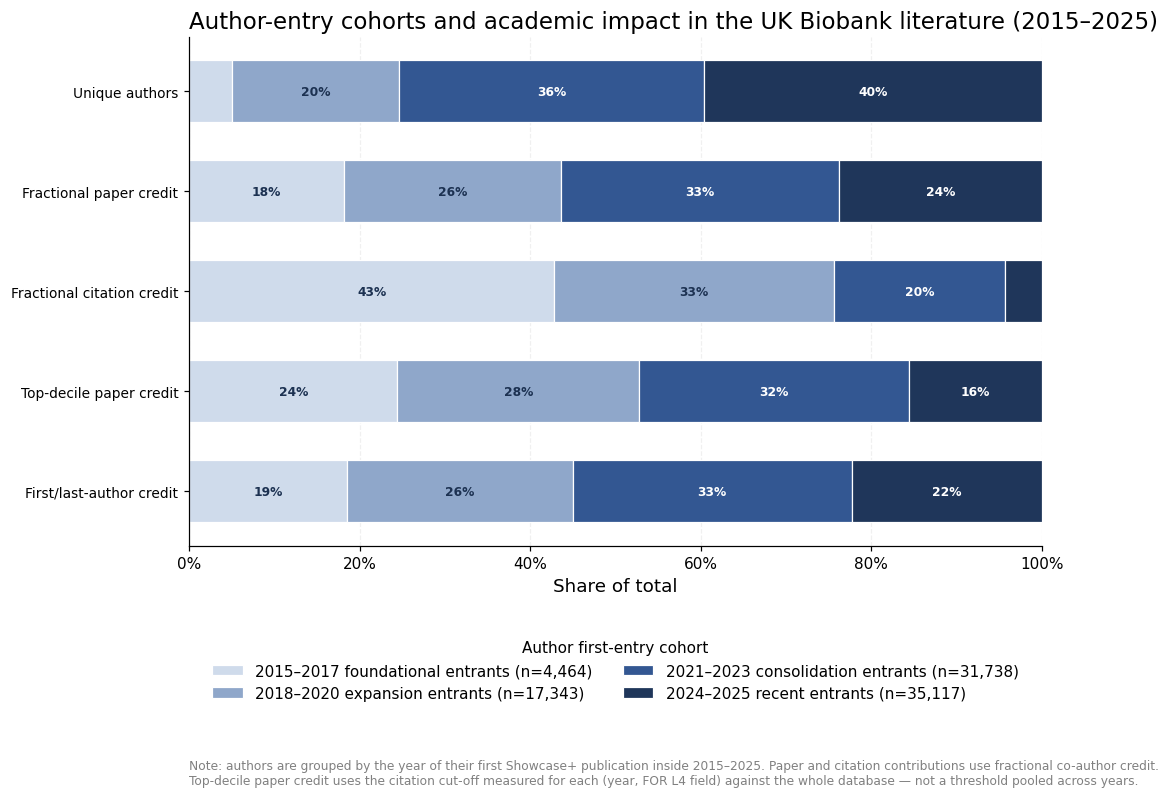


cohort shares (%), 2015-2025:

  Unique authors               2015–2017   5.0%  2018–2020  19.6%  2021–2023  35.8%  2024–2025  39.6%
  Fractional paper credit      2015–2017  18.1%  2018–2020  25.6%  2021–2023  32.5%  2024–2025  23.8%
  Fractional citation credit   2015–2017  42.8%  2018–2020  32.8%  2021–2023  20.1%  2024–2025   4.3%
  Top-decile paper credit      2015–2017  24.4%  2018–2020  28.3%  2021–2023  31.7%  2024–2025  15.6%
  First/last-author credit     2015–2017  18.5%  2018–2020  26.5%  2021–2023  32.7%  2024–2025  22.3%


In [6]:
# ============================================================
# 6. Candidate Fig. 3a — Author-entry cohort contribution profile
# ============================================================
# Was UK Biobank's impact produced mainly by early foundational contributors, or by
# successive waves of researchers entering the literature?
#
# READ THE TOP-DECILE ROW AGAINST ITS OWN HISTORY. Under the pooled FCR cut-off this
# notebook used before the reconcile, that row was substantially a measure of paper
# age and the earliest cohort dominated it by construction. It is now the measured
# per-(year, field) decile, so a 2024 paper is judged against 2024's bar and the row
# says something about the work rather than about the calendar.

cohort_author = author_summary[author_summary["entry_cohort"].isin(cohort_order)].copy()
cohort_author["entry_cohort"] = pd.Categorical(cohort_author["entry_cohort"],
                                               categories=cohort_order, ordered=True)
cohort_paper = author_paper[author_paper["entry_cohort"].isin(cohort_order)].copy()
cohort_paper["entry_cohort"] = pd.Categorical(cohort_paper["entry_cohort"],
                                              categories=cohort_order, ordered=True)

_by_author = cohort_author.groupby("entry_cohort", observed=True)
_by_paper = cohort_paper.groupby("entry_cohort", observed=True)
unique_author_counts = _by_author["author_key"].nunique()

contrib = pd.DataFrame({
    "Unique authors": unique_author_counts,
    "Fractional paper credit": _by_paper["fractional_paper_credit"].sum(),
    "Fractional citation credit": _by_paper["fractional_citation_credit"].sum(),
    "Top-decile paper credit": _by_paper["fractional_top_decile_credit"].sum(),
    "First/last-author credit": _by_paper["leadership_author_credit"].sum(),
}).T
contrib = contrib[cohort_order].fillna(0)
contrib_share = contrib.div(contrib.sum(axis=1), axis=0)

contrib_share.to_csv(TABLE_DIR / "fig3a_author_entry_cohort_contribution_shares.csv")
contrib.to_csv(TABLE_DIR / "fig3a_author_entry_cohort_contribution_raw.csv")

display(contrib.round(2))
display((100 * contrib_share).round(1))

fig, ax = plt.subplots(figsize=STYLE["figsize_small"])
y = np.arange(len(contrib_share.index))
left = np.zeros(len(contrib_share))

for i, cohort in enumerate(cohort_order):
    vals = contrib_share[cohort].values
    ax.barh(y, vals, left=left, height=0.62, color=cohort_palette[i],
            edgecolor="white", linewidth=0.8, label=cohort.replace("\n", " "))
    for yi, x0, v in zip(y, left, vals):
        if v >= 0.065:
            ax.text(x0 + v / 2, yi, f"{100 * v:.0f}%", ha="center", va="center",
                    fontsize=STYLE["annot_fs"] - 1,
                    color="white" if i >= 2 else INK, fontweight="bold")
    left += vals

ax.set_yticks(y)
ax.set_yticklabels(contrib_share.index, fontsize=STYLE["annot_fs"])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Share of total")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title(f"Author-entry cohorts and academic impact in the UK Biobank literature "
             f"({ANALYSIS_MIN}–{ANALYSIS_MAX})",
             loc="left", fontsize=STYLE["title_fs"])
ax.grid(axis="x", color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)

cohort_ns = unique_author_counts.reindex(cohort_order).fillna(0).astype(int)
handles, _ = ax.get_legend_handles_labels()
# Legend then note, both in AXES fractions: laid out in figure coordinates they were
# positioned independently of the axes height and the note met the legend title.
ax.legend(handles,
          [f"{c.replace(chr(10), ' ')} (n={cohort_ns[c]:,})" for c in cohort_order],
          loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False,
          title="Author first-entry cohort", fontsize=STYLE["legend_fs"])

ax.annotate(
         ("Note: authors are grouped by the year of their first Showcase+ publication "
          f"inside {ANALYSIS_MIN}–{ANALYSIS_MAX}. Paper and citation contributions use "
          "fractional co-author credit.\nTop-decile paper credit uses the citation "
          f"cut-off measured for each (year, FOR {FOR_LEVEL} field) against the whole "
          "database — not a threshold pooled across years."),
         (0, -0.42), xycoords="axes fraction",
         ha="left", va="top", fontsize=STYLE["annot_fs"] - 1, color=GREY)

savefig(fig, "fig3a_author_entry_cohort_academic_impact_profile")
plt.show()

print(f"\ncohort shares (%), {ANALYSIS_MIN}-{ANALYSIS_MAX}:\n")
for row in contrib_share.index:
    parts = "  ".join(f"{c.split(chr(10))[0]} {100 * contrib_share.loc[row, c]:5.1f}%"
                      for c in cohort_order)
    print(f"  {row:<28s} {parts}")


,author_name,ukb_influence_score,showcase_paper_count,fractional_paper_credit,fractional_citation_credit,showcase_h_index,mean_impact_metric,fractional_top_decile_credit,leadership_share,active_span_years
0,Rory Collins,98.633744,49,3.114371,1612.780772,25,23.721565,1.263811,0.102041,11
1,Peter Donnelly,98.438079,18,1.747667,698.974993,12,27.048916,1.056724,0.333333,10
2,Adrian Cortes,98.245934,22,2.015942,650.185372,12,22.819085,0.547656,0.227273,10
3,Lloyd T. Elliott,98.228677,17,1.604681,823.596046,11,28.638120,0.831918,0.235294,9
4,Paul M. Matthews,98.169193,61,5.964912,1165.968231,31,16.520300,1.820387,0.180328,11
5,Olivier Delaneau,98.161997,30,4.280384,907.610026,15,18.105128,1.631534,0.533333,11
6,Jonathan Marchini,98.154621,54,5.911600,1206.499822,26,16.329504,2.645017,0.277778,11
7,Naomi Allen,98.130146,102,12.215923,2283.794502,38,15.102137,3.574779,0.235294,11
8,Cathie Sudlow,98.108987,70,6.227241,1665.637156,35,15.084451,2.471749,0.271429,11
9,Christian Benner,98.041540,24,1.809263,337.970566,17,22.014204,0.860787,0.125000,9


saved output/figures/data_analysis/03_academic_impact/fig_author_influence_fingerprint_heatmap.pdf


saved output/figures/data_analysis/03_academic_impact/fig_author_influence_fingerprint_heatmap.png


saved output/figures/data_analysis/03_academic_impact/fig_author_influence_fingerprint_heatmap.svg


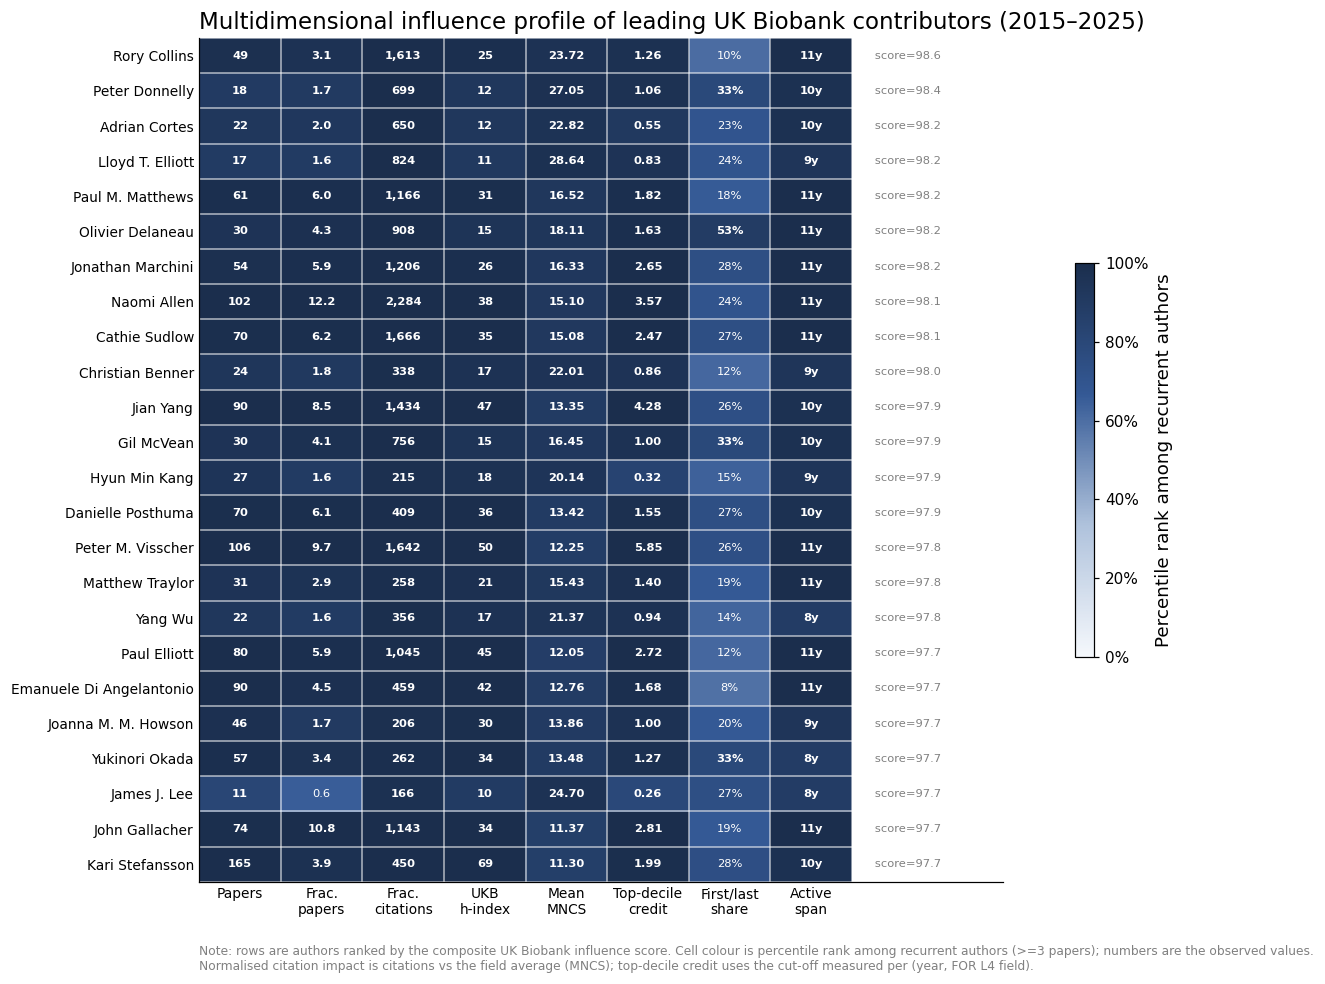

In [7]:
# ============================================================
# 8. Supplement — Influential-author fingerprint heatmap
# ============================================================
# A leaderboard says who is ahead; this says what each of them is ahead ON. Rows are
# the top authors by composite score, columns the dimensions that make them
# influential. Cell colour is the percentile rank among RECURRENT authors, so a cell
# is read against the field of contributors rather than against the 24 shown.

fingerprint_source = author_summary[author_summary["showcase_paper_count"] >= 3].copy()
if fingerprint_source.empty:
    fingerprint_source = author_summary.copy()

top_n = 24
fingerprint = author_summary.head(top_n).copy()

metric_specs = [
    # Every label is two lines. On one line "Frac. papers", "Frac. citations" and
    # "UKB h-index" run into each other at this column width.
    ("showcase_paper_count", "Papers", lambda x: f"{int(x):,}"),
    ("fractional_paper_credit", "Frac.\npapers", lambda x: f"{x:.1f}"),
    ("fractional_citation_credit", "Frac.\ncitations", lambda x: f"{x:,.0f}"),
    ("showcase_h_index", "UKB\nh-index", lambda x: f"{int(x):,}"),
    ("mean_impact_metric", f"Mean\n{IMPACT_SHORT}", lambda x: f"{x:.2f}"),
    # A sum of fractional credits, not a paper count: a paper top-decile in one of its
    # two fields contributes 0.5, shared again across its co-authors.
    ("fractional_top_decile_credit", "Top-decile\ncredit", lambda x: f"{x:.2f}"),
    ("leadership_share", "First/last\nshare", lambda x: f"{100 * x:.0f}%"),
    ("active_span_years", "Active\nspan", lambda x: f"{int(x)}y"),
]

norm_matrix, raw_text = [], []
for col, label, fmt in metric_specs:
    ranks = pct_rank_safe(fingerprint_source[col])
    rank_map = pd.Series(ranks.values, index=fingerprint_source["author_key"])
    norm_matrix.append(fingerprint["author_key"].map(rank_map).fillna(0).values)
    raw_text.append([fmt(v) if pd.notna(v) else "" for v in fingerprint[col].values])

norm_matrix = np.array(norm_matrix).T
raw_text = np.array(raw_text).T

fingerprint[["author_name", "ukb_influence_score"] + [m[0] for m in metric_specs]].to_csv(
    TABLE_DIR / "fig_author_influence_fingerprint_top_authors.csv", index=False)

display(fingerprint[["author_name", "ukb_influence_score"]
                    + [m[0] for m in metric_specs]].head(top_n))

fig_height = max(7.2, 0.34 * len(fingerprint) + 1.8)
fig, ax = plt.subplots(figsize=(10.5, fig_height))

im = ax.imshow(norm_matrix, aspect="auto", cmap=UKB_SEQ, vmin=0, vmax=1)

ax.set_yticks(np.arange(len(fingerprint)))
ax.set_yticklabels(fingerprint["author_name"].fillna(""), fontsize=STYLE["annot_fs"])
ax.set_xticks(np.arange(len(metric_specs)))
ax.set_xticklabels([m[1] for m in metric_specs], rotation=0, ha="center",
                   fontsize=STYLE["annot_fs"])

for i in range(norm_matrix.shape[0]):
    for j in range(norm_matrix.shape[1]):
        val = norm_matrix[i, j]
        ax.text(j, i, raw_text[i, j], ha="center", va="center",
                fontsize=STYLE["annot_fs"] - 1.5,
                color="white" if val > 0.58 else INK,
                fontweight="bold" if val > 0.78 else "normal")

# Thin white cell boundaries.
ax.set_xticks(np.arange(-0.5, len(metric_specs), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(fingerprint), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.1)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

ax.set_title(f"Multidimensional influence profile of leading UK Biobank contributors "
             f"({ANALYSIS_MIN}–{ANALYSIS_MAX})",
             loc="left", fontsize=STYLE["title_fs"])
ax.set_xlim(-0.5, len(metric_specs) + 1.35)

for i, (_, r) in enumerate(fingerprint.iterrows()):
    ax.text(len(metric_specs) - 0.35, i, f"   score={r['ukb_influence_score']:.1f}",
            ha="left", va="center", fontsize=STYLE["annot_fs"] - 1.5, color=GREY)

cbar = fig.colorbar(im, ax=ax, fraction=0.022, pad=0.08)
cbar.set_label("Percentile rank among recurrent authors")
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Anchored on the AXES, not the figure: at fig y=-0.045 the note sat an inch and a
# half below a 24-row panel and tight-bbox kept all of that whitespace.
ax.annotate(
         ("Note: rows are authors ranked by the composite UK Biobank influence score. "
          "Cell colour is percentile rank among recurrent authors (>=3 papers); "
          "numbers are the observed values.\nNormalised citation impact is "
          f"{IMPACT_LABEL} ({IMPACT_SHORT}); top-decile credit uses the cut-off "
          f"measured per (year, FOR {FOR_LEVEL} field)."),
         (0, -0.075), xycoords="axes fraction",
         ha="left", va="top", fontsize=STYLE["annot_fs"] - 1, color=GREY)

savefig(fig, "fig_author_influence_fingerprint_heatmap")
plt.show()
